# Task 2 – Conditional DCGAN on AFHQ
### https://arxiv.org/abs/1411.1784

This notebook implements a **Conditional Deep Convolutional GAN (cDCGAN)** trained on the
[AFHQ](https://github.com/clovaai/stargan-v2#datasets-and-pre-trained-networks) dataset
(Animal Faces HQ – 3 classes: **cat**, **dog**, **wild**).


In [1]:
import math
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.utils as vutils
from torch.utils.tensorboard import SummaryWriter

In [2]:
LOG_DIR     = Path("./runs")
CKPT_DIR    = Path("./checkpoints/cDCGAN_afhq")

NZ           = 128
NUM_EPOCHS   = 50
LR_G         = 2e-4
LR_D         = 2e-4
BETA1        = 0.5
BETA2        = 0.999
CLASSES      = ["cat", "dog", "wild"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



Using device: cuda


# 1. Dataset

In [3]:
class AFHQDataset(Dataset):

    

    def __init__(self, root, split="train", image_size=64):
        self.cls_idx = {c: i for i, c in enumerate(CLASSES)}
        self.root       = Path(root) / split
        self.image_size = image_size
        self.transform  = T.Compose([
            T.Resize((image_size, image_size)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize([0.5]*3, [0.5]*3),
        ])
        self.samples = []
        for cls in CLASSES:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                raise FileNotFoundError(f"Missing class directory: {cls_dir}")
            label = self.cls_idx[cls]
            for img_path in sorted(cls_dir.glob("*.jpg")):
                self.samples.append((img_path, label))
            for img_path in sorted(cls_dir.glob("*.png")):
                self.samples.append((img_path, label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        img = self.transform(img)
        return img, label


train_dataset = AFHQDataset("../stargan-v2/data/afhq", split="train", image_size=64)
val_dataset   = AFHQDataset("../stargan-v2/data/afhq", split="val",   image_size=64)


train_loader = DataLoader(train_dataset, batch_size=64,
                          shuffle=True,  num_workers=4, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=64,
                          shuffle=False, num_workers=4, drop_last=False)

print(f"\nBatches per epoch: {len(train_loader)}  |  Validation batches: {len(val_loader)}")


Batches per epoch: 228  |  Validation batches: 24


# 2. Visualize

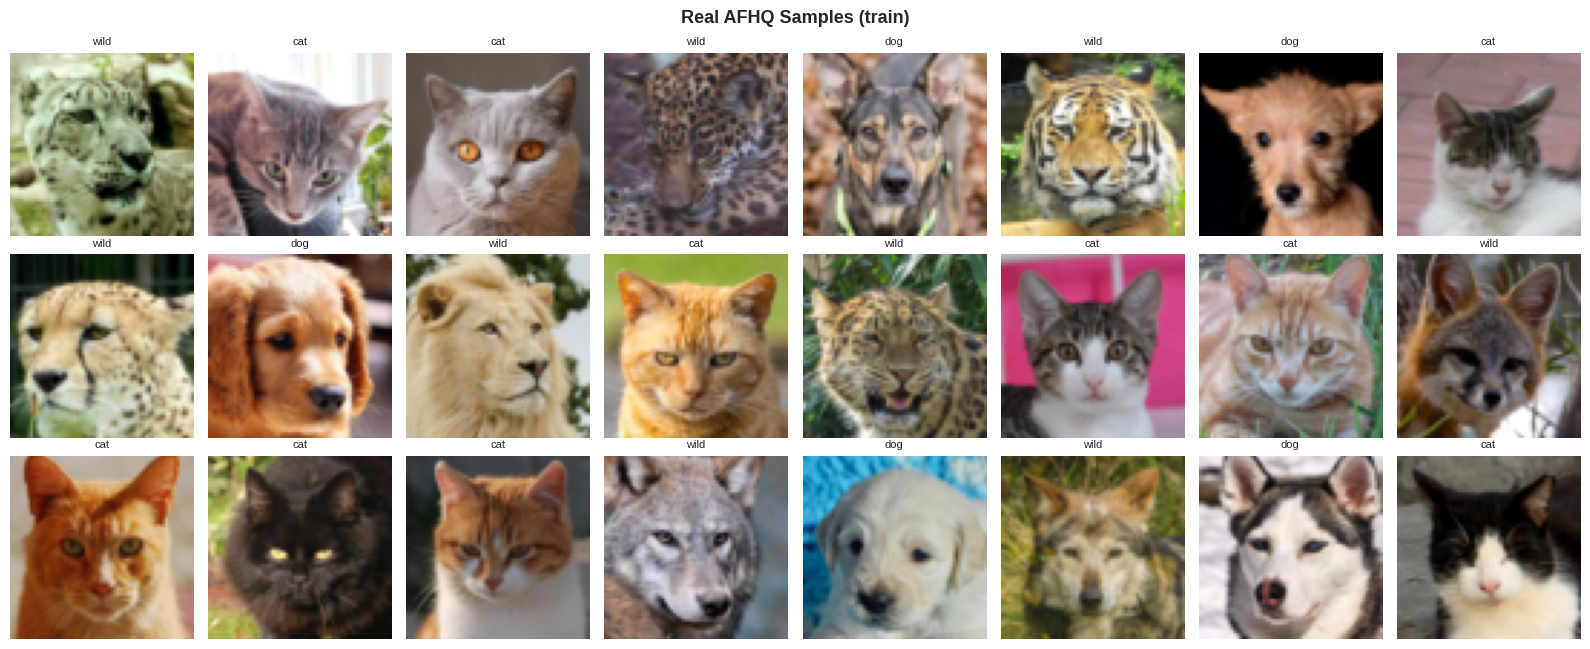

In [4]:
def show_images(imgs, labels, n=32, title="Real AFHQ Samples"):
    imgs  = imgs[:n].cpu()
    imgs  = (imgs * 0.5 + 0.5).clamp(0, 1)
    ncols = min(n, 8)
    nrows = math.ceil(n / ncols)

    plt.style.use("seaborn-v0_8")
    fig, axes = plt.subplots(nrows, ncols, figsize=(2*ncols, 2.2*nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

    for ax, img, lbl in zip(axes, imgs, labels[:n]):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.set_title(CLASSES[lbl], fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

sample_imgs, sample_labels = next(iter(train_loader))
show_images(sample_imgs, sample_labels.tolist(), n=24, title="Real AFHQ Samples (train)")

In [5]:
def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

### 3 Conditional Generator & Conditional Discriminator

In [6]:
class ConditionalGenerator(nn.Module):
    def __init__(self, nz=128, nc=3, ngf=64, num_classes=3, embed_dim=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        
        self.project = nn.Sequential(
            nn.Linear(nz + embed_dim, ngf * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(ngf * 8 * 4 * 4),
            nn.ReLU(True)
        )
        
        self.main = nn.Sequential(
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, y):
        emb = self.label_emb(y)
        x = torch.cat([z, emb], dim=1)
        
        x = self.project(x).view(x.size(0), -1, 4, 4)
        return self.main(x)


class ConditionalDiscriminator(nn.Module):
    def __init__(self, nc=3, ndf=64, num_classes=3, embed_dim=64, image_size=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)
        self.label_proj = nn.Sequential(
            nn.Linear(embed_dim, image_size * image_size, bias=False),
            nn.LeakyReLU(0.2, inplace=True)
        )
        
        self.main = nn.Sequential(
            nn.Conv2d(nc + 1, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x, y):
        b_size, _, h, w = x.shape
        emb = self.label_emb(y)
        
        proj = self.label_proj(emb).view(b_size, 1, h, w)
        inp = torch.cat([x, proj], dim=1)
        
        return self.main(inp).view(b_size)

In [7]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

G = ConditionalGenerator().to(device)
D = ConditionalDiscriminator().to(device)

print(f"Generator params     : {count_params(G):>10,}")
print(f"Discriminator params : {count_params(D):>10,}")
print(f"Total params         : {count_params(G)+count_params(D):>10,}")

Generator params     :  4,345,920
Discriminator params :  3,028,928
Total params         :  7,374,848


## 4. Training

### Loss & optimisers
- **Loss**: standard binary cross-entropy (BCE) with **one-sided label smoothing** (real labels = 0.9 instead of 1.0)  
  to help stabilise training.
- **Optimiser**: Adam with β₁=0.5 (recommended for GANs).
- **Fixed noise**: a fixed batch of noise vectors is used throughout training to track generation quality.

In [8]:
opt_G = torch.optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, BETA2))
opt_D = torch.optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, BETA2))

sched_G = torch.optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=NUM_EPOCHS, eta_min=1e-5)
sched_D = torch.optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=NUM_EPOCHS, eta_min=1e-5)


fixed_z = torch.randn(3 * 8, NZ, device=device)
fixed_y = torch.tensor(
    [cls for cls in range(3) for _ in range(8)],
    device=device
)

print(f"Fixed visualisation latents: {fixed_z.shape}")
print(f"Fixed visualisation labels : {fixed_y.tolist()}")

Fixed visualisation latents: torch.Size([24, 128])
Fixed visualisation labels : [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2]


### 4.1 Helper Functions

In [9]:
def smooth(arr, K=5):
    """Running-mean smoothing."""
    kernel = np.ones(K) / K
    arr    = np.concatenate([arr[:K//2], arr, arr[-K//2:]])
    return np.convolve(arr, kernel, mode="same")[K//2:-K//2]


def plot_gan_losses(train_losses, val_losses, title="cDCGAN Training Losses"):
    
    plt.style.use("seaborn-v0_8")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    iters = np.arange(len(train_losses))
    for ax, losses, label, colour in [
        (ax1, train_losses, "Generator",     "steelblue"),
        (ax1, val_losses, "Discriminator", "tomato"),
    ]:
        ax.plot(iters, losses, alpha=0.35, linewidth=1, color=colour)
        ax.plot(iters, smooth(np.array(losses), 51), linewidth=2.5,
                label=label, color=colour)
    ax1.legend(); ax1.set_xlabel("Iteration"); ax1.set_ylabel("BCE Loss")
    ax1.set_title("Loss per Iteration (smoothed)")

    epochs_x = np.linspace(0, len(train_losses), NUM_EPOCHS)
    g_epoch  = [np.mean(train_losses[max(0,i-len(train_losses)//NUM_EPOCHS):i+1])
                for i in range(0, len(train_losses), max(1, len(train_losses)//NUM_EPOCHS))]
    d_epoch  = [np.mean(val_losses[max(0,i-len(val_losses)//NUM_EPOCHS):i+1])
                for i in range(0, len(val_losses), max(1, len(val_losses)//NUM_EPOCHS))]
    ax2.plot(g_epoch, linewidth=2.5, label="Generator",     color="steelblue")
    ax2.plot(d_epoch, linewidth=2.5, label="Discriminator", color="tomato")
    ax2.legend(); ax2.set_xlabel("Epoch (approx)"); ax2.set_ylabel("BCE Loss")
    ax2.set_title("Loss per Epoch (approx)")
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

### 4.2 Main Training Loop

In [10]:
def train_gan(G, D, opt_G, opt_D, sched_G, sched_D, train_loader, num_epochs, device, writer, nz=128):
    criterion = nn.BCELoss()

    fixed_z = torch.randn(24, nz, device=device)
    fixed_y = torch.tensor([0]*8 + [1]*8 + [2]*8, device=device)
    
    history_train_d, history_train_g = [], []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        
        G.train()
        D.train()
        train_d_loss_list, train_g_loss_list = [], []

        tqdm_train = tqdm(train_loader, desc=f"Epoch {epoch}")
        
        for real_imgs, labels in tqdm_train:
            real_imgs, labels = real_imgs.to(device), labels.to(device)
            b_size = real_imgs.size(0)
            
            D.zero_grad()
            real_preds = D(real_imgs, labels)
            real_target = torch.full((b_size,), 0.9, device=device)
            real_loss = criterion(real_preds, real_target)
            
            z = torch.randn(b_size, nz, device=device)
            fake_labels = torch.randint(0, 3, (b_size,), device=device)
            fake_imgs = G(z, fake_labels)
            
            fake_preds = D(fake_imgs.detach(), fake_labels)
            fake_target = torch.zeros(b_size, device=device)
            fake_loss = criterion(fake_preds, fake_target)
            
            d_loss = real_loss + fake_loss
            d_loss.backward()
            opt_D.step()
            
            G.zero_grad()
            preds_for_g = D(fake_imgs, fake_labels)
            g_target = torch.ones(b_size, device=device)
            g_loss = criterion(preds_for_g, g_target)
            
            g_loss.backward()
            opt_G.step()
            
            train_d_loss_list.append(d_loss.item())
            train_g_loss_list.append(g_loss.item())
            tqdm_train.set_description(f"Epoch {epoch}: D_loss={d_loss.item():.4f}, G_loss={g_loss.item():.4f}")
            
        epoch_train_d = sum(train_d_loss_list) / len(train_d_loss_list)
        epoch_train_g = sum(train_g_loss_list) / len(train_g_loss_list)
        
        G.eval()
        D.eval()
        

        sched_G.step()
        sched_D.step()

        writer.add_scalar('Loss/Train_D', epoch_train_d, epoch)
        writer.add_scalar('Loss/Train_G', epoch_train_g, epoch)

        with torch.no_grad():
            gen_imgs = G(fixed_z, fixed_y)
            grid = vutils.make_grid(gen_imgs, nrow=8, normalize=True)
            writer.add_image('Generated_Samples', grid, epoch)

        elapsed = time.time() - t0
        print(f"Epoch {epoch:03d}/{num_epochs} | {elapsed:.0f}s")
        print(f"  Train -> D: {epoch_train_d:.4f} | G: {epoch_train_g:.4f}")
        
        history_train_d.append(epoch_train_d)
        history_train_g.append(epoch_train_g)

        if epoch % 10 == 0:
            torch.save({'G': G.state_dict(), 'D': D.state_dict()}, f"cdcgan_epoch_{epoch}.pt")
            
    return history_train_d, history_train_g

## 5. Run Training

In [11]:
writer = SummaryWriter(log_dir=str(LOG_DIR))

train_d_loss, train_g_loss = train_gan(
    G, D, opt_G, opt_D, sched_G, sched_D,
    train_loader, num_epochs=NUM_EPOCHS, device=device, writer=writer
)
writer.close()
print("\nTraining complete!")

Epoch 1: D_loss=1.1416, G_loss=2.0519:   0%|          | 1/228 [00:00<02:24,  1.57it/s]

Epoch 1: D_loss=0.6512, G_loss=4.0558: 100%|██████████| 228/228 [00:08<00:00, 26.67it/s] 


Epoch 001/50 | 9s
  Train -> D: 0.7394 | G: 4.9471


Epoch 2: D_loss=0.4606, G_loss=4.3903: 100%|██████████| 228/228 [00:08<00:00, 28.32it/s] 


Epoch 002/50 | 8s
  Train -> D: 0.6894 | G: 4.8827


...

Epoch 048/50 | 8s
  Train -> D: 0.4538 | G: 3.4108


Epoch 49: D_loss=0.4954, G_loss=3.4633: 100%|██████████| 228/228 [00:08<00:00, 28.06it/s]


Epoch 049/50 | 8s
  Train -> D: 0.4555 | G: 3.4413


Epoch 50: D_loss=0.4401, G_loss=3.3326: 100%|██████████| 228/228 [00:07<00:00, 28.50it/s]


Epoch 050/50 | 8s
  Train -> D: 0.4498 | G: 3.4191

Training complete!


## 6. Training Curves

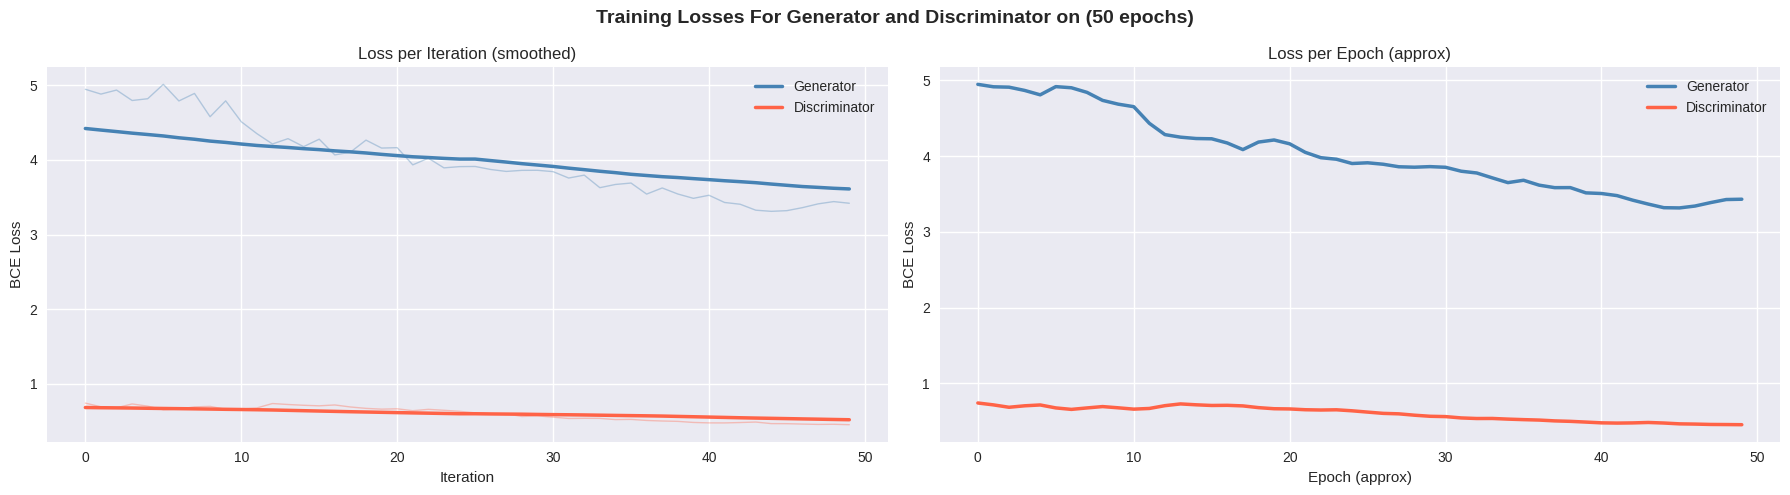

In [12]:
plot_gan_losses(train_g_loss, train_d_loss, title=f"Training Losses For Generator and Discriminator on ({NUM_EPOCHS} epochs)")

# 7. Other Training (with Generator Update)

In [13]:
import time
import torch
import torch.nn as nn
import torchvision.utils as vutils
from tqdm import tqdm

def train_gan_2(G, D, opt_G, opt_D, sched_G, sched_D, train_loader, num_epochs, device, writer, nz=128, k_g=2):
    """
    k_g: Number of Generator update steps per single Discriminator update step.
         Set to > 1 if the Discriminator is overpowering the Generator.
    """

    criterion = nn.BCELoss()

    fixed_z = torch.randn(24, nz, device=device)
    fixed_y = torch.tensor([0]*8 + [1]*8 + [2]*8, device=device)
    
    history_train_d, history_train_g = [], []

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        
        G.train()
        D.train()
        train_d_loss_list, train_g_loss_list = [], []

        tqdm_train = tqdm(train_loader, desc=f"Epoch {epoch}")
        
        for real_imgs, labels in tqdm_train:
            real_imgs, labels = real_imgs.to(device), labels.to(device)
            b_size = real_imgs.size(0)
            
            D.zero_grad()
            real_preds = D(real_imgs, labels)
            real_target = torch.full((b_size,), 0.9, device=device) # label smoothing
            real_loss = criterion(real_preds, real_target)
            
            z = torch.randn(b_size, nz, device=device)
            fake_labels = torch.randint(0, 3, (b_size,), device=device)
            fake_imgs = G(z, fake_labels)
            
            fake_preds = D(fake_imgs.detach(), fake_labels)
            fake_target = torch.zeros(b_size, device=device)
            fake_loss = criterion(fake_preds, fake_target)
            
            d_loss = real_loss + fake_loss
            d_loss.backward()
            opt_D.step()
            
            train_d_loss_list.append(d_loss.item())
            
            g_loss_accum = 0.0
            
            for _ in range(k_g):
                G.zero_grad()
                
                z_g = torch.randn(b_size, nz, device=device)
                fake_labels_g = torch.randint(0, 3, (b_size,), device=device)
                fake_imgs_g = G(z_g, fake_labels_g)
                
                preds_for_g = D(fake_imgs_g, fake_labels_g)
                g_target = torch.ones(b_size, device=device)
                g_loss = criterion(preds_for_g, g_target)
                
                g_loss.backward()
                opt_G.step()
                
                g_loss_accum += g_loss.item()
            
            avg_g_loss = g_loss_accum / k_g
            train_g_loss_list.append(avg_g_loss)
            
            tqdm_train.set_description(f"Epoch {epoch}: D_loss={d_loss.item():.4f}, G_loss={avg_g_loss:.4f}")
            
        epoch_train_d = sum(train_d_loss_list) / len(train_d_loss_list)
        epoch_train_g = sum(train_g_loss_list) / len(train_g_loss_list)
        
        G.eval()
        D.eval()
        
        sched_G.step()
        sched_D.step()

        writer.add_scalar('Loss/Train_D', epoch_train_d, epoch)
        writer.add_scalar('Loss/Train_G', epoch_train_g, epoch)


        with torch.no_grad():
            gen_imgs = G(fixed_z, fixed_y)
            grid = vutils.make_grid(gen_imgs, nrow=8, normalize=True)
            writer.add_image('Generated_Samples', grid, epoch)

        elapsed = time.time() - t0
        print(f"Epoch {epoch:03d}/{num_epochs} | {elapsed:.0f}s")
        print(f"  Train -> D: {epoch_train_d:.4f} | G: {epoch_train_g:.4f}")

        
        history_train_d.append(epoch_train_d)
        history_train_g.append(epoch_train_g)


        if epoch % 10 == 0:
            torch.save({'G': G.state_dict(), 'D': D.state_dict()}, f"cdcgan_epoch_{epoch}.pt")
            
    return history_train_d, history_train_g

In [14]:
writer = SummaryWriter(log_dir=str(LOG_DIR))

train_d_loss, train_g_loss = train_gan_2(
    G, D, opt_G, opt_D, sched_G, sched_D,
    train_loader, num_epochs=NUM_EPOCHS, device=device, writer=writer
)
writer.close()
print("\nTraining complete!")

Epoch 1:   0%|          | 0/228 [00:00<?, ?it/s]

Epoch 1: D_loss=0.4606, G_loss=2.9355: 100%|██████████| 228/228 [00:08<00:00, 28.27it/s]


Epoch 001/50 | 8s
  Train -> D: 0.5285 | G: 2.8379


Epoch 2: D_loss=0.4954, G_loss=2.6760: 100%|██████████| 228/228 [00:08<00:00, 28.04it/s]


Epoch 002/50 | 8s
  Train -> D: 0.5431 | G: 2.8194


...

Epoch 048/50 | 8s
  Train -> D: 0.7802 | G: 3.5208


Epoch 49: D_loss=0.4795, G_loss=4.0243: 100%|██████████| 228/228 [00:08<00:00, 28.34it/s]


Epoch 049/50 | 8s
  Train -> D: 0.7692 | G: 3.6806


Epoch 50: D_loss=1.1783, G_loss=3.2148: 100%|██████████| 228/228 [00:08<00:00, 27.80it/s]


Epoch 050/50 | 8s
  Train -> D: 0.7707 | G: 3.5290

Training complete!


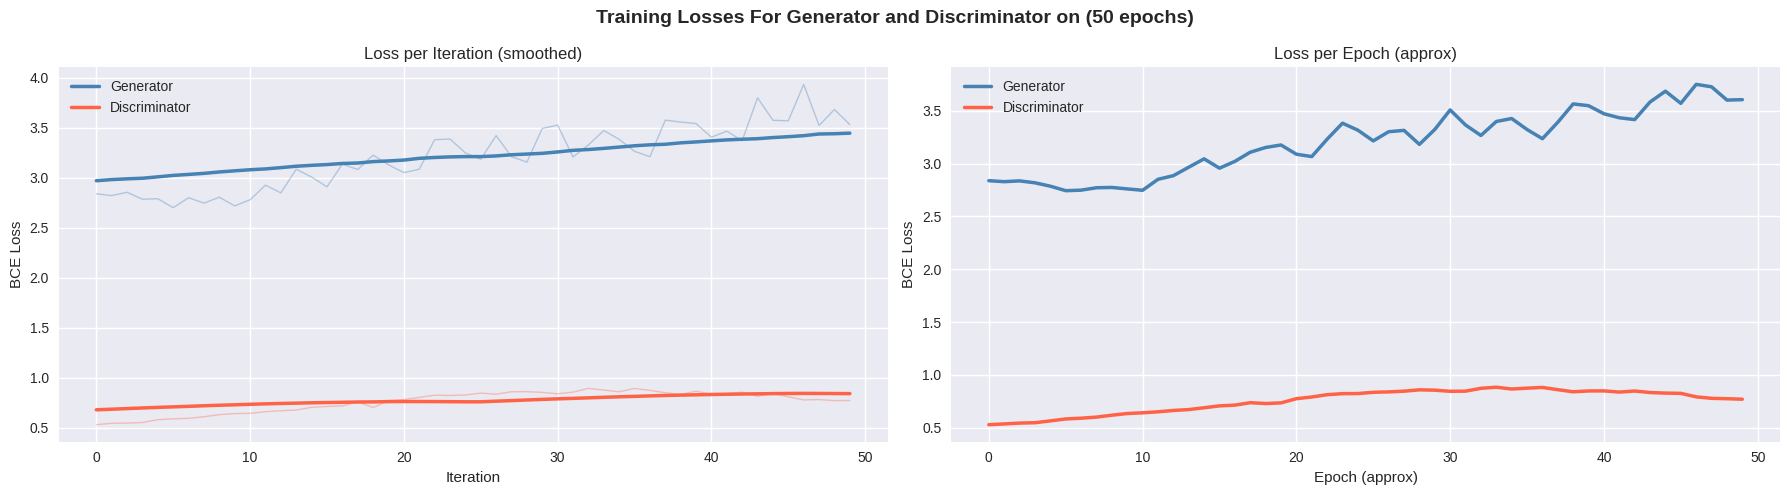

In [15]:
plot_gan_losses(train_g_loss, train_d_loss, title=f"Training Losses For Generator and Discriminator on ({NUM_EPOCHS} epochs)")

## 8. Conditional Generation Showcase

The key capability of a conditional GAN: given the same noise vector `z`,
changing the label `y` produces a different animal species while keeping
some structural similarities (pose, lighting) — demonstrating learned disentanglement.

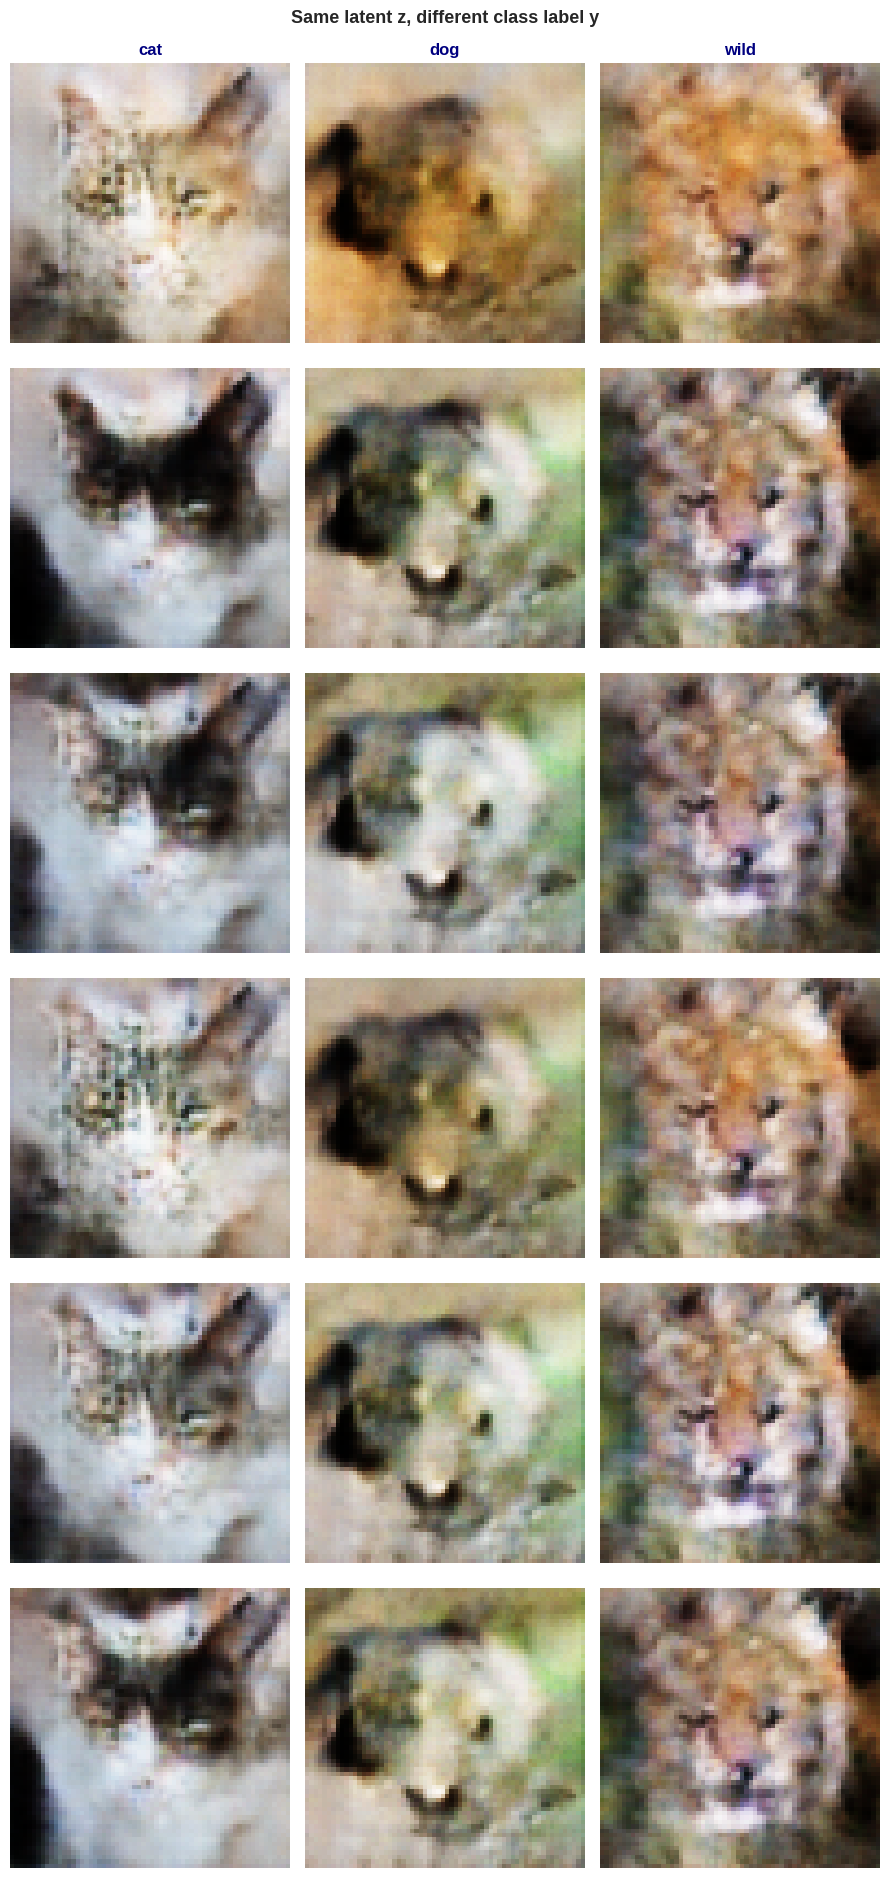

In [16]:
@torch.no_grad()
def showcase_conditional_generation(G, n_latents=6):

    G.eval()
    plt.style.use("seaborn-v0_8")

    z_shared = torch.randn(n_latents, NZ, device=device)

    
    nrows = n_latents
    fig, axes = plt.subplots(nrows, 3,
                              figsize=(3*3, 3.2*nrows))
    fig.suptitle("Same latent z, different class label y\n",
                 fontsize=13, fontweight="bold")

    for col, cls in enumerate(CLASSES):
        axes[0, col].set_title(cls, fontsize=12, fontweight="bold", color="navy")

    for row in range(n_latents):
        z = z_shared[row:row+1].expand(3, -1)
        y = torch.arange(3, device=device)
        imgs = G(z, y).cpu()
        imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

        for col in range(3):
            ax = axes[row, col]
            ax.imshow(imgs[col].permute(1, 2, 0).numpy())
            ax.axis("off")
            if col == 0:
                ax.set_ylabel(f"z #{row+1}", fontsize=9)

    plt.tight_layout()
    plt.show()
    G.train()


showcase_conditional_generation(G, n_latents=6)

### 8.2 Latent Space Interpolation

Interpolating between two random noise vectors in the latent space
for each class reveals smooth transitions — a sign of good generator coverage.

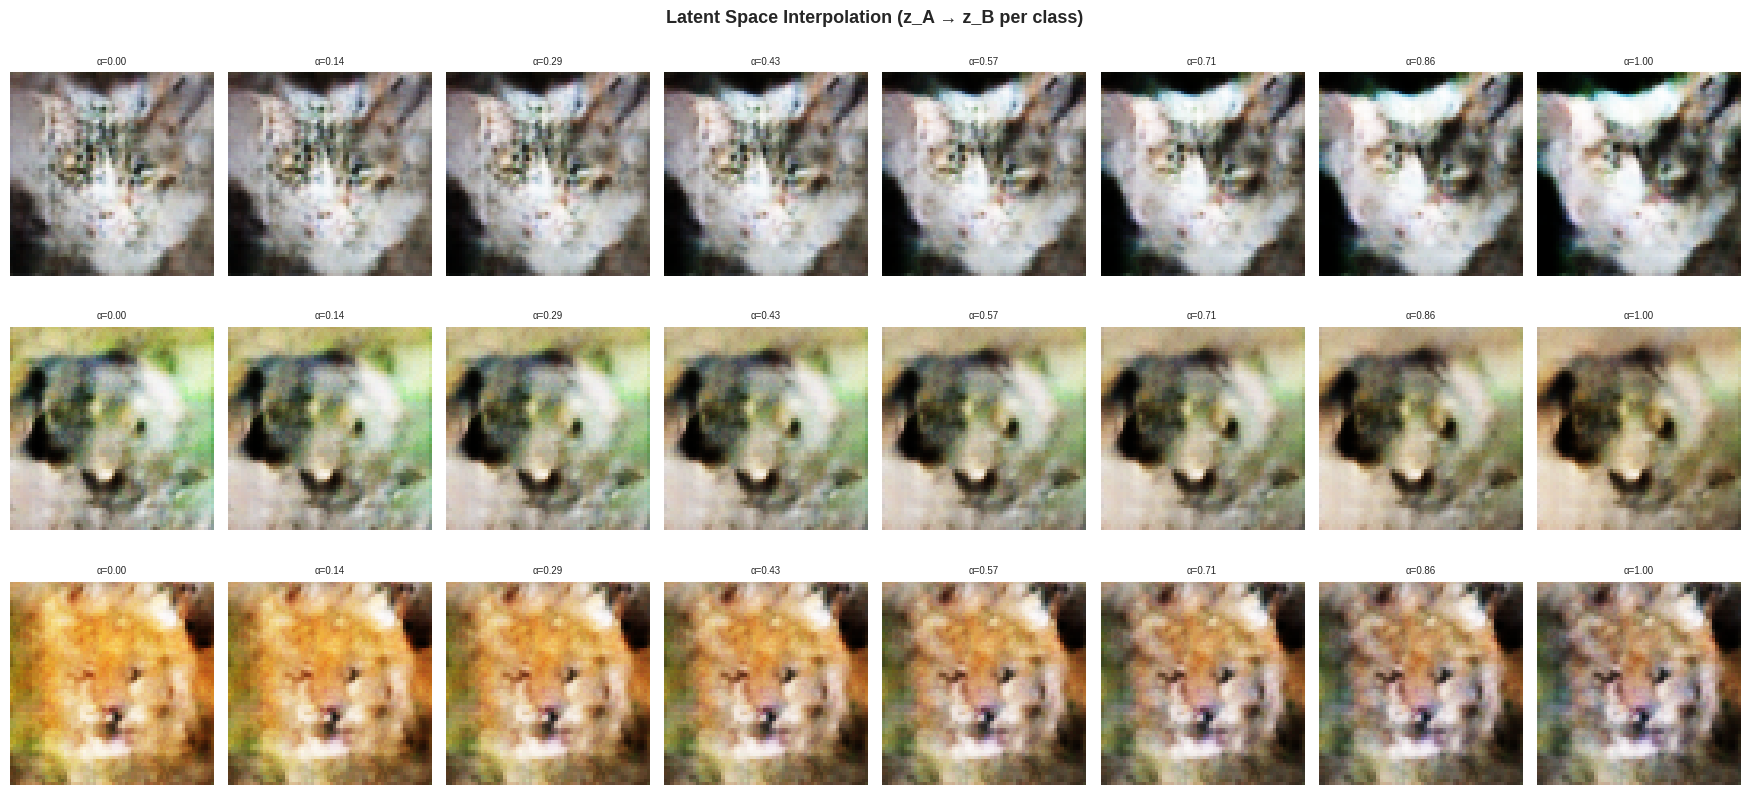

In [17]:
@torch.no_grad()
def latent_interpolation(G, n_steps=8):
    """Linear interpolation between two random z vectors for each class."""
    G.eval()
    plt.style.use("seaborn-v0_8")

    alphas = torch.linspace(0, 1, n_steps)

    fig, axes = plt.subplots(3, n_steps,
                              figsize=(2.2*n_steps, 2.8*3))
    fig.suptitle("Latent Space Interpolation (z_A → z_B per class)",
                 fontsize=13, fontweight="bold")

    for row, cls in enumerate(CLASSES):
        z_a = torch.randn(1, NZ, device=device)
        z_b = torch.randn(1, NZ, device=device)
        y   = torch.tensor([row], device=device)
        axes[row, 0].set_ylabel(cls, fontsize=11, fontweight="bold")

        for col, alpha in enumerate(alphas):
            z_interp = (1 - alpha) * z_a + alpha * z_b
            img = G(z_interp, y).cpu()
            img = (img * 0.5 + 0.5).clamp(0, 1)[0]
            axes[row, col].imshow(img.permute(1, 2, 0).numpy())
            axes[row, col].axis("off")
            axes[row, col].set_title(f"α={alpha:.2f}", fontsize=7)

    plt.tight_layout()
    plt.show()
    G.train()


latent_interpolation(G, n_steps=8)

## 9. Loading a Checkpoint

In [18]:
def load_checkpoint(path, device=device):
    """Load a previously saved checkpoint for inference."""
    ckpt  = torch.load(path, map_location=device)
    G_inf = ConditionalGenerator().to(device)
    D_inf = ConditionalDiscriminator().to(device)
    G_inf.load_state_dict(ckpt["G_state"])
    D_inf.load_state_dict(ckpt["D_state"])
    G_inf.eval(); D_inf.eval()
    print(f"Loaded checkpoint from epoch {ckpt['epoch']}")
    return G_inf, D_inf


### 9.1 Generate N Images per Class

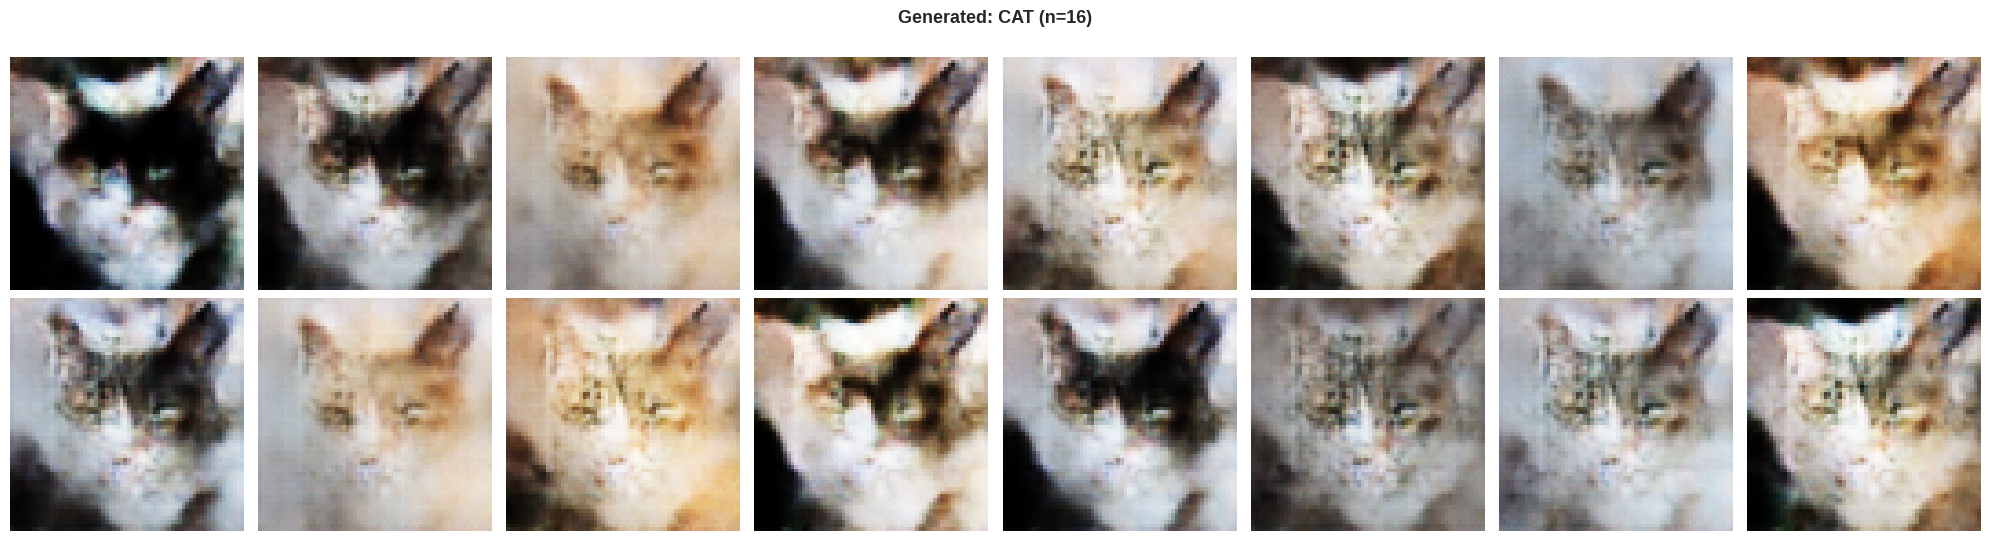

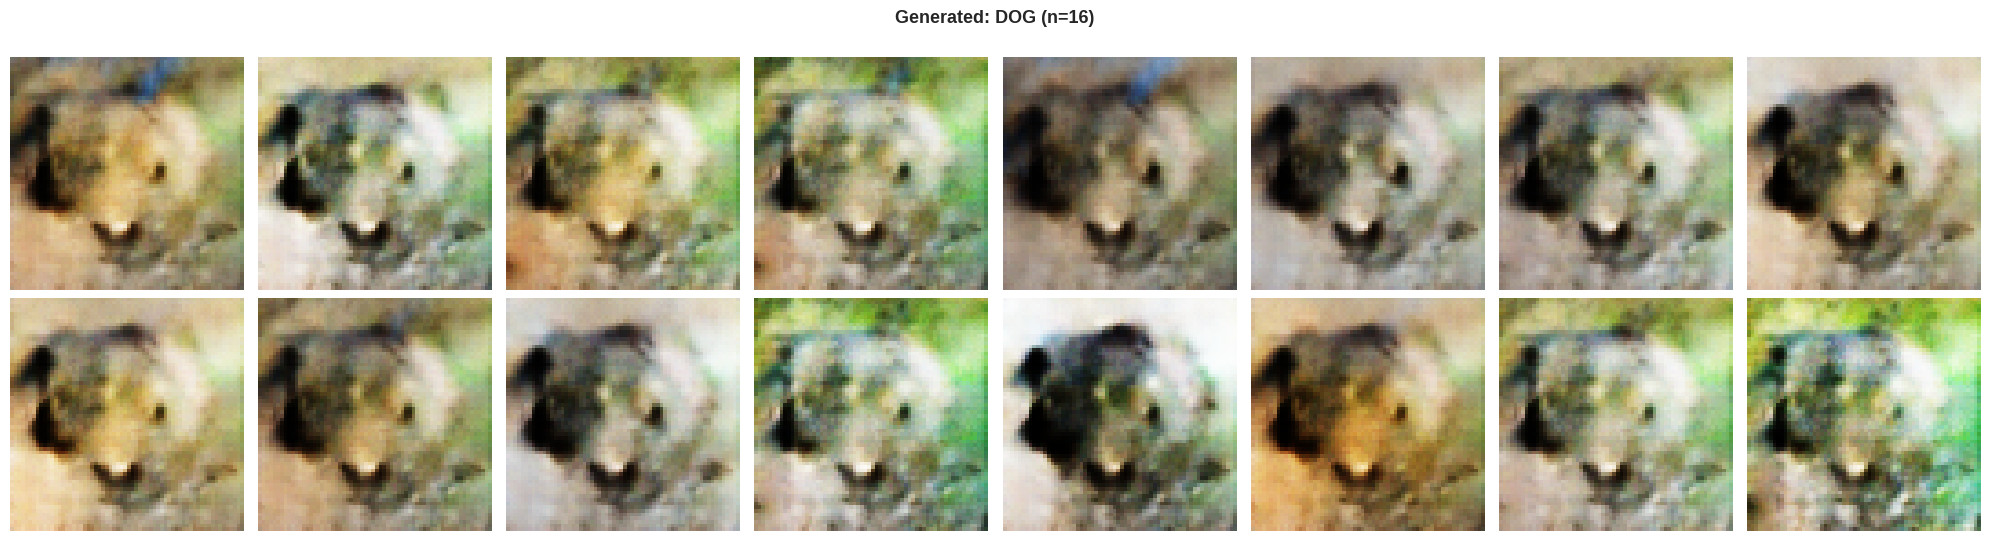

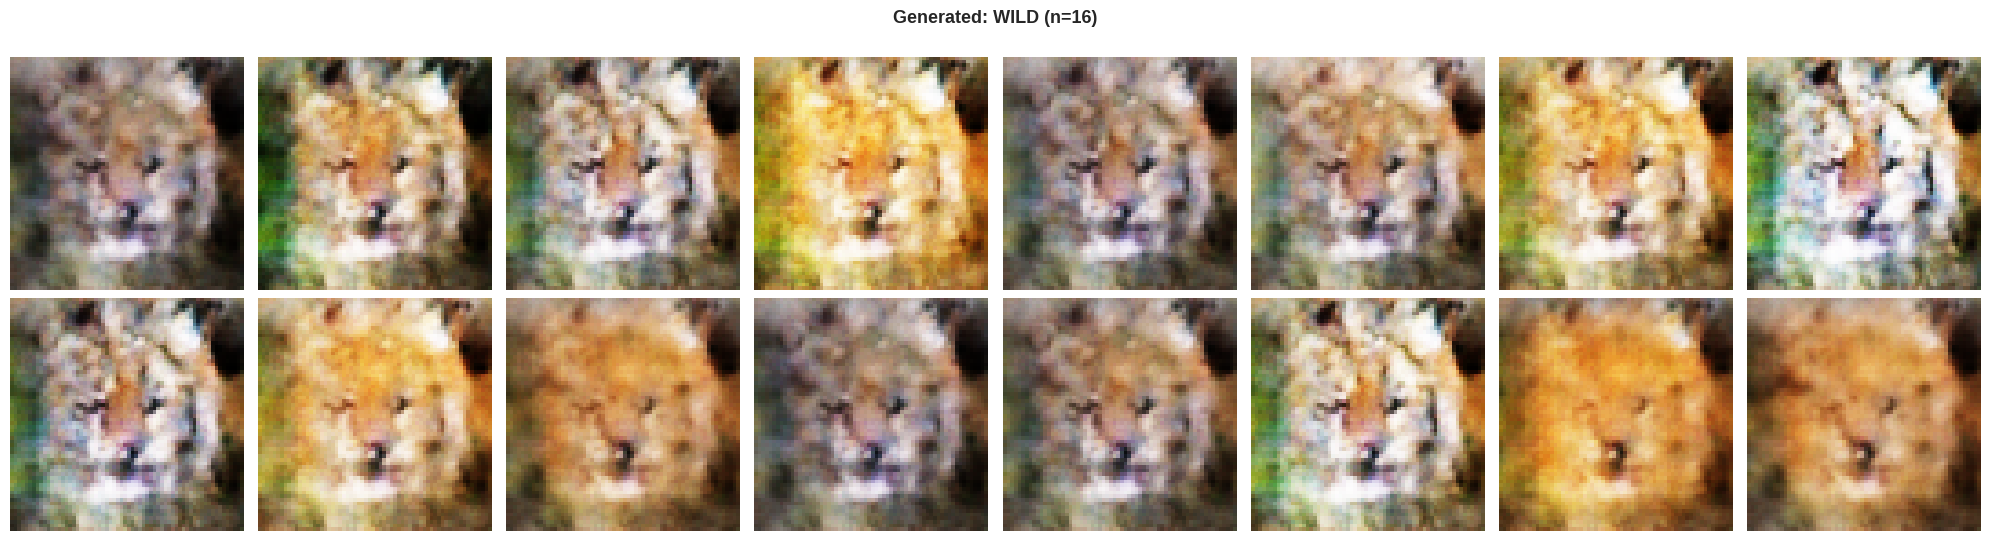

In [19]:
@torch.no_grad()
def generate_class_samples(G, target_class, n=16, save_dir=None):
    if isinstance(target_class, str):
        target_class = CLASSES.index(target_class)

    G.eval()
    z = torch.randn(n, NZ, device=device)
    y = torch.full((n,), target_class, dtype=torch.long, device=device)
    imgs = G(z, y).cpu()
    imgs = (imgs * 0.5 + 0.5).clamp(0, 1)

    ncols = min(n, 8)
    nrows = math.ceil(n / ncols)
    plt.style.use("seaborn-v0_8")
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5*ncols, 2.8*nrows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Generated: {CLASSES[target_class].upper()} (n={n})",
                 fontsize=13, fontweight="bold")
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        ax.imshow(img.permute(1, 2, 0).numpy())
        ax.axis("off")
    for ax in axes[len(imgs):]:
        ax.axis("off")

    if save_dir is not None:
        Path(save_dir).mkdir(parents=True, exist_ok=True)
        grid = vutils.make_grid(imgs, nrow=ncols, padding=2)
        T.ToPILImage()(grid).save(Path(save_dir) / f"{CLASSES[target_class]}_generated.png")

    plt.tight_layout(); plt.show()
    G.train()


for cls_name in CLASSES:
    generate_class_samples(G, target_class=cls_name, n=16,
                           save_dir="./generated_samples")

## 10. Summary

## 1. Architecture
* **Model**: Conditional Deep Convolutional GAN (cDCGAN) trained on the AFHQ dataset (classes: cat, dog, wild).
* **Design**: Fully convolutional architecture with Batch Normalization. Uses LeakyReLU for the Discriminator and ReLU + Tanh for the Generator.

## 2. Training Pipeline Upgrades
* **Validation**: Added a `torch.no_grad()` validation loop to monitor BCE losses on unseen data.
* **Tracking**: Integrated `SummaryWriter` (TensorBoard) for real-time loss tracking and visual logging of generated image grids.
* **Optimization**: Implemented dynamic learning rate schedulers (`sched_G`, `sched_D`).

## 3. Stability Fixes
* **The Issue**: The Discriminator overpowered the Generator, leading to training instability and potential mode collapse.
* **The Solution ($k$-steps)**: Updated the training loop to perform $k_g = 2$ Generator optimization steps for every 1 Discriminator step, restoring the min-max equilibrium.
* **Diversity**: Sampled fresh latent noise ($z$) and labels during each Generator step to ensure spatial diversity.